# Apple Stock Price Prediction

### Objective:
#### forecasts Apple stock prices for the next 30 days using historical stock data from 2012 to 2019. The model will help investors, traders, and financial analysts make informed decisions based on stock trends and potential market movements.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

## Data Preprocessing

In [56]:
## dataset
df = pd.read_csv("P625 DATASET.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)
df = df.sort_index()

In [57]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


In [58]:
## shape
df.shape

(2011, 6)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2011 entries, 2012-01-03 to 2019-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2011 non-null   float64
 1   High       2011 non-null   float64
 2   Low        2011 non-null   float64
 3   Close      2011 non-null   float64
 4   Adj Close  2011 non-null   float64
 5   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 110.0 KB


In [60]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2.011000e+03
mean,126.707469,127.827594,125.580258,126.741235,119.505548,5.949670e+07
std,50.483753,50.926301,50.124940,50.578369,52.438444,4.683856e+07
min,55.424286,57.085712,55.014286,55.790001,48.921928,1.136200e+07
25%,85.882858,86.717858,85.056427,86.202145,75.056679,2.758565e+07
50%,113.050003,114.190002,111.870003,113.050003,105.222908,4.346900e+07
75%,165.190002,167.409996,163.424995,165.245002,160.047111,7.471030e+07
max,291.119995,293.970001,288.119995,291.519989,289.522614,3.765300e+08


In [61]:
## missing values
df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [62]:
## duplicated values
df.duplicated().sum()

np.int64(0)

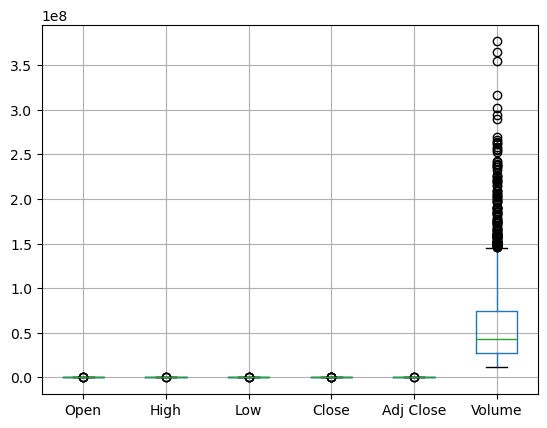

In [63]:
## outliers
df.boxplot()
plt.show()

In [36]:
df['Close_scaled'] = scaler.fit_transform(df[['Close']])
df.head()

,Open,High,Low,Close,Adj Close,Volume,Close_scaled
Date,,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200,0.012545
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500,0.013884
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400,0.016666
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200,0.019314
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100,0.018908


In [35]:
## scaling
scaler = MinMaxScaler()
df1 = scaler.fit_transform(df[['Open','High','Low','Close','Adj Close','Volume']])
df1 = pd.DataFrame(df1, columns=['Open','High','Low','Close','Adj Close','Volume'])
df1.head(10)

,Open,High,Low,Close,Adj Close,Volume
0,0.012989,0.007780,0.014647,0.012545,0.007663,0.175791
1,0.013353,0.009094,0.014819,0.013884,0.008797,0.146901
2,0.016353,0.011428,0.016896,0.016666,0.011152,0.154601
3,0.019274,0.013961,0.020910,0.019314,0.013394,0.186794
4,0.022747,0.016976,0.022216,0.018908,0.013051,0.238641
5,0.022996,0.015921,0.022307,0.019823,0.013825,0.145651
6,0.021038,0.014021,0.020965,0.019405,0.013471,0.116136
7,0.020796,0.014051,0.020622,0.018702,0.012876,0.114426
8,0.019232,0.012574,0.020567,0.017744,0.012066,0.123624
9,0.021959,0.015915,0.023202,0.020708,0.014574,0.135177


## Exploratory Data Analysis (EDA) 

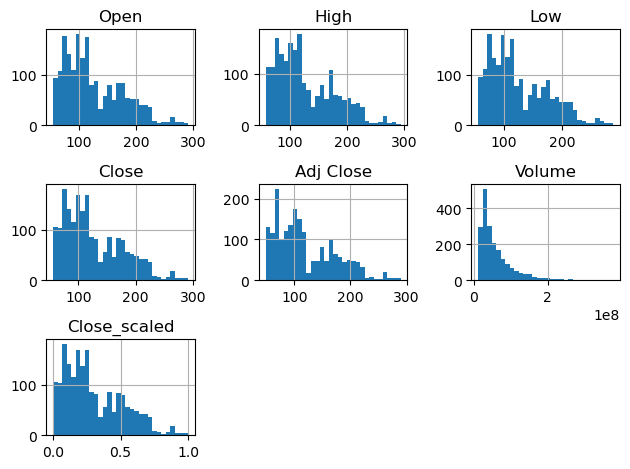

In [11]:
# Plot histogram
df.hist(bins=30)
plt.tight_layout()
plt.show()

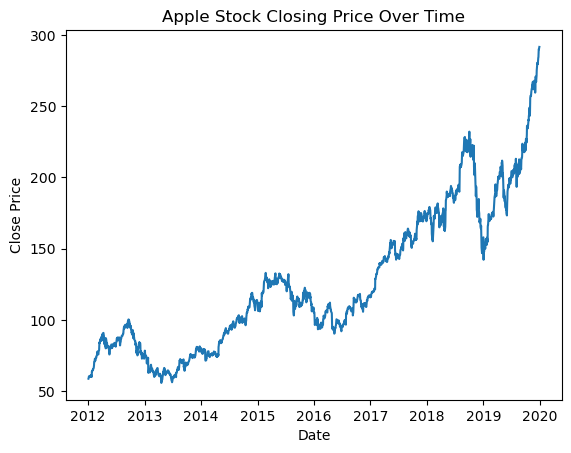

In [12]:
plt.plot(df.index, df['Close'])
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Apple Stock Closing Price Over Time")
plt.show()

In [13]:
decomposition = seasonal_decompose(df['Close'], model='additive', period=252)

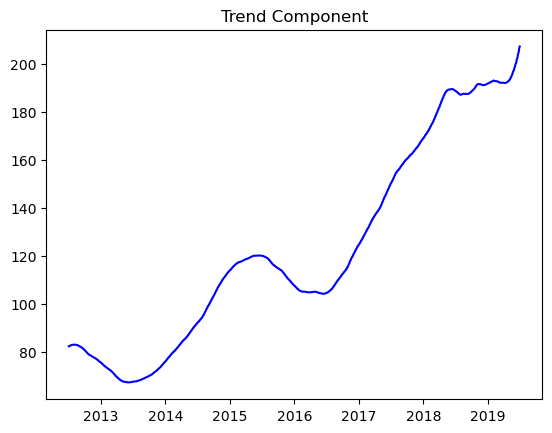

In [14]:
## trend
plt.plot(decomposition.trend, color='blue')
plt.title("Trend Component")
plt.show()

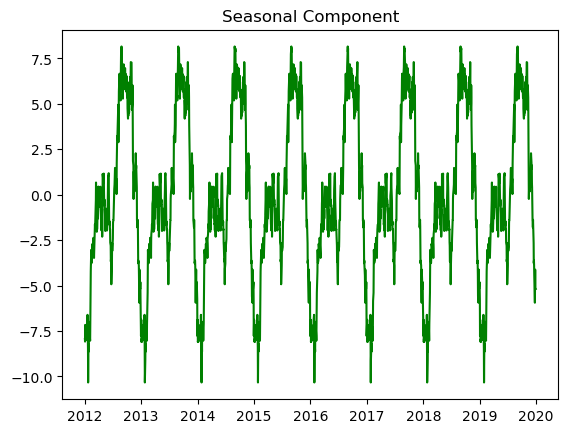

In [15]:
## seasonality
plt.plot(decomposition.seasonal, color='green')
plt.title("Seasonal Component")
plt.show()

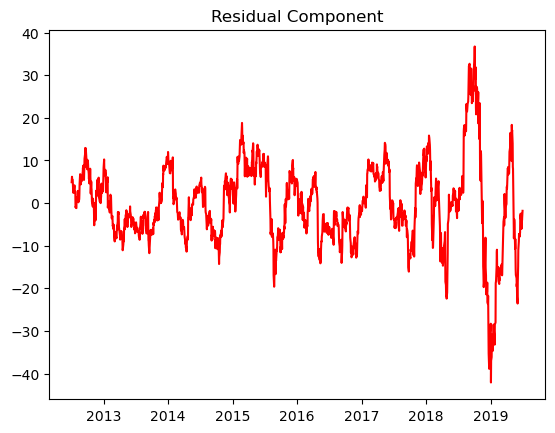

In [16]:
## residual
plt.plot(decomposition.resid, color='red')
plt.title("Residual Component")
plt.show()

## Feature Engineering 

In [17]:
## moving averages
df['MA_7'] = df['Close'].rolling(7).mean()
df['MA_14'] = df['Close'].rolling(14).mean()
df['MA_30'] = df['Close'].rolling(30).mean()

In [18]:
df.tail()

,Open,High,Low,Close,Adj Close,Volume,Close_scaled,MA_7,MA_14,MA_30
Date,,,,,,,,,,
2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000,0.968099,279.802852,273.877138,268.701334
2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700,0.969244,281.105708,275.486424,269.436999
2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300,0.993170,282.541425,277.224282,270.368667
2019-12-27,291.119995,293.970001,288.119995,289.799988,287.814392,36566500,0.992704,283.882852,278.587853,271.212999
2019-12-30,289.459991,292.690002,285.220001,291.519989,289.522614,36028600,1.000000,285.565709,280.344995,272.175665


In [19]:
## volatality
df['Volatility'] = df['Close'].rolling(window=14).std()

In [20]:
df.tail()

,Open,High,Low,Close,Adj Close,Volume,Close_scaled,MA_7,MA_14,MA_30,Volatility
Date,,,,,,,,,,,
2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000,0.968099,279.802852,273.877138,268.701334,6.820951
2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700,0.969244,281.105708,275.486424,269.436999,6.380702
2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300,0.993170,282.541425,277.224282,270.368667,6.776053
2019-12-27,291.119995,293.970001,288.119995,289.799988,287.814392,36566500,0.992704,283.882852,278.587853,271.212999,7.267290
2019-12-30,289.459991,292.690002,285.220001,291.519989,289.522614,36028600,1.000000,285.565709,280.344995,272.175665,7.202838


In [21]:
## Lag Features
df['Lag_7'] = df['Close'].shift(1)
df['Lag_14'] = df['Close'].shift(7)
df['Lag_30'] = df['Close'].shift(14)

In [22]:
df.tail()

,Open,High,Low,Close,Adj Close,Volume,Close_scaled,MA_7,MA_14,MA_30,Volatility,Lag_7,Lag_14,Lag_30
Date,,,,,,,,,,,,,,
2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000,0.968099,279.802852,273.877138,268.701334,6.820951,279.440002,271.459991,259.450012
2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700,0.969244,281.105708,275.486424,269.436999,6.380702,284.000000,275.149994,261.739990
2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300,0.993170,282.541425,277.224282,270.368667,6.776053,284.269989,279.859985,265.579987
2019-12-27,291.119995,293.970001,288.119995,289.799988,287.814392,36566500,0.992704,283.882852,278.587853,271.212999,7.267290,289.910004,280.410004,270.709991
2019-12-30,289.459991,292.690002,285.220001,291.519989,289.522614,36028600,1.000000,285.565709,280.344995,272.175665,7.202838,289.799988,279.739990,266.920013


In [23]:
# Calculate daily returns
df['Return'] = df['Close'].pct_change()

In [24]:
df.tail()

,Open,High,Low,Close,Adj Close,Volume,Close_scaled,MA_7,MA_14,MA_30,Volatility,Lag_7,Lag_14,Lag_30,Return
Date,,,,,,,,,,,,,,,
2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000,0.968099,279.802852,273.877138,268.701334,6.820951,279.440002,271.459991,259.450012,0.016318
2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700,0.969244,281.105708,275.486424,269.436999,6.380702,284.000000,275.149994,261.739990,0.000951
2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300,0.993170,282.541425,277.224282,270.368667,6.776053,284.269989,279.859985,265.579987,0.019840
2019-12-27,291.119995,293.970001,288.119995,289.799988,287.814392,36566500,0.992704,283.882852,278.587853,271.212999,7.267290,289.910004,280.410004,270.709991,-0.000379
2019-12-30,289.459991,292.690002,285.220001,291.519989,289.522614,36028600,1.000000,285.565709,280.344995,272.175665,7.202838,289.799988,279.739990,266.920013,0.005935


In [25]:
df['rolling_mean_5'] = df['Close'].rolling(5).mean()
df['rolling_std_5'] = df['Close'].rolling(5).std()

## Stationarity

In [26]:
from statsmodels.tsa.stattools import adfuller,acf,pacf
import statsmodels.tsa.api as smt

In [27]:
## select only close col
df1=df['Close']
df1 = df1.to_frame(name='Close')

In [28]:
## stationarity check
def test_stationarity(timeseries):
    #Calculate rolling mean and rolling standard deviation
    rolmean = timeseries.rolling(window = 30).mean()
    rolstd = timeseries.rolling(window = 30).std()

    original = plt.plot(timeseries, color = 'blue', label = 'Original')
    mean = plt.plot(rolmean, color = 'red', label = 'Rolling Mean')
    std = plt.plot(rolstd, color = 'green', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.show()
    
    print('Results of Dickey-Fuller Test :\n')
    df_test = adfuller(timeseries)
    my_output = pd.Series(df_test[0:4], index =['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for i,j in df_test[4].items():
        my_output['Critical Value (%s)'%i] =j
    print(my_output)

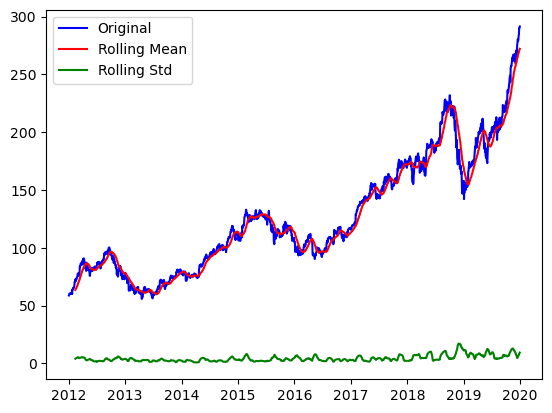

Results of Dickey-Fuller Test :

Test Statistic                    1.219370
p-value                           0.996117
#Lags Used                        9.000000
Number of Observations Used    2001.000000
Critical Value (1%)              -3.433622
Critical Value (5%)              -2.862985
Critical Value (10%)             -2.567540
dtype: float64


In [29]:
test_stationarity(df1['Close'])

In [30]:
## differencing
df1['Close_diff'] = df1['Close'].diff()
# Remove NaN value created by differencing
df_diff = df1['Close_diff'].dropna()

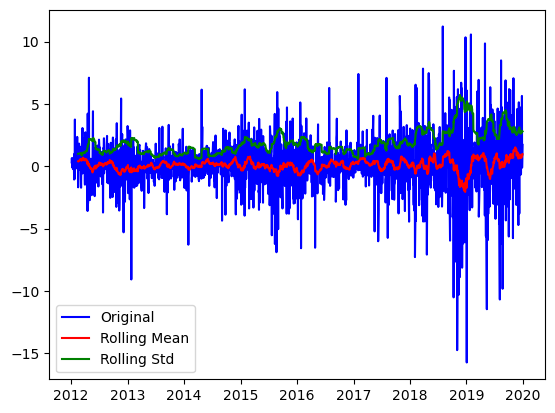

Results of Dickey-Fuller Test :

Test Statistic                -1.362553e+01
p-value                        1.763123e-25
#Lags Used                     8.000000e+00
Number of Observations Used    2.001000e+03
Critical Value (1%)           -3.433622e+00
Critical Value (5%)           -2.862985e+00
Critical Value (10%)          -2.567540e+00
dtype: float64


In [31]:
test_stationarity(df_diff)

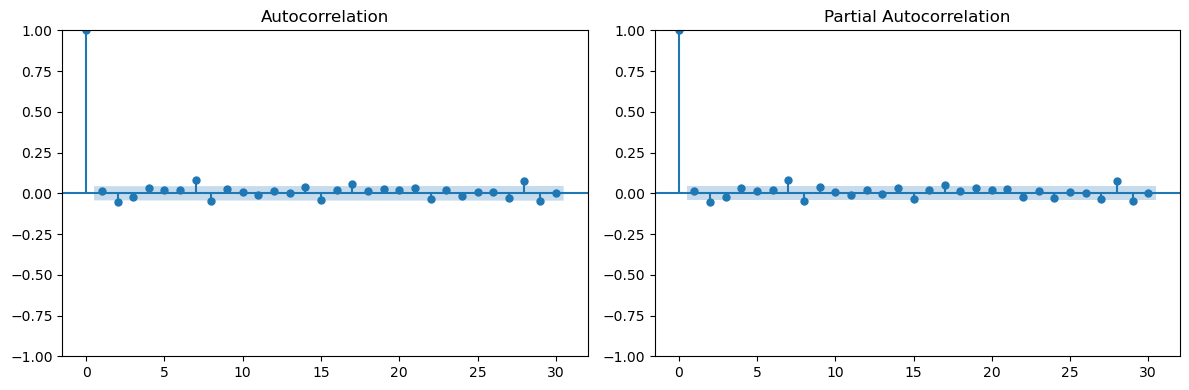

In [32]:
## ploting acf and pacf for p and q
fig, axes = plt.subplots(1, 2)
fig.set_figwidth(12)
fig.set_figheight(4)
smt.graphics.plot_acf(df_diff, lags=30, ax=axes[0])
smt.graphics.plot_pacf(df_diff, lags=30, ax=axes[1])
plt.tight_layout()
plt.show()

### ARIMA

In [33]:
from statsmodels.tsa.arima.model import ARIMA

In [34]:
## select only close col
ts=df['Close']

In [35]:
# Train-test split
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

In [36]:
## train the model
model = ARIMA(train, order=(0,1,0), trend='t')
model_fit = model.fit()

In [37]:
# Prediction
start = len(train)
end = len(train) + len(test) - 1
pred = model_fit.predict(start=start, end=end)
pred.index = test.index

In [38]:
# Evaluation
arima_mae = mean_absolute_error(test, pred)
arima_rmse = np.sqrt(mean_squared_error(test, pred))
print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 20.755122718211364
ARIMA RMSE: 26.370172928018757


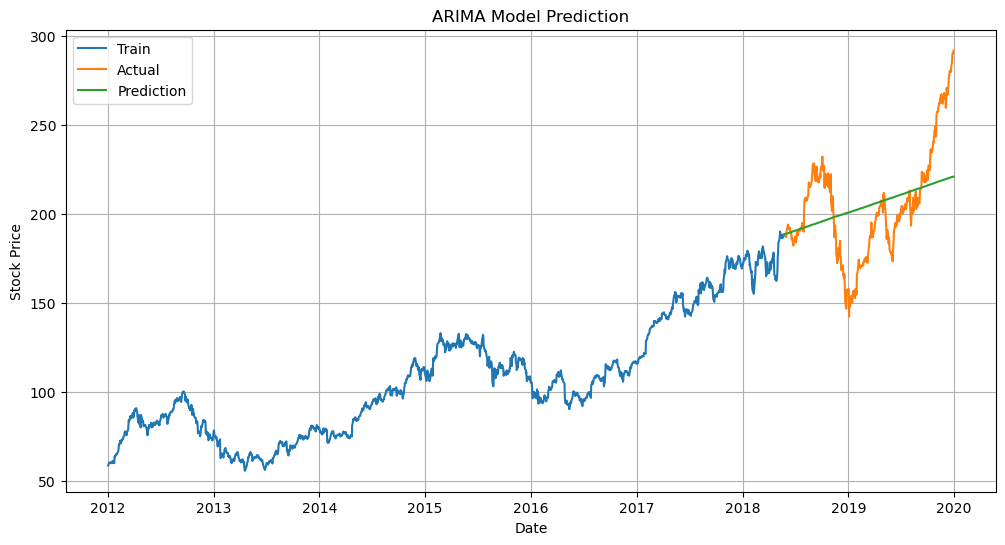

In [39]:
# Plot train,actual and predicted
plt.figure(figsize=(12,6))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(pred, label='Prediction')
plt.title("ARIMA Model Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
# future forecast
future_forecast = model_fit.forecast(steps=30)
future_dates = pd.date_range(start=ts.index[-1], periods=30+1, freq='B')[1:]
# Convert to Series
future_forecast = pd.Series(future_forecast.values, index=future_dates)
future_forecast

2019-12-31    188.440651
2020-01-01    188.521301
2020-01-02    188.601951
2020-01-03    188.682602
2020-01-06    188.763252
2020-01-07    188.843902
2020-01-08    188.924552
2020-01-09    189.005202
2020-01-10    189.085852
2020-01-13    189.166503
2020-01-14    189.247153
2020-01-15    189.327803
2020-01-16    189.408453
2020-01-17    189.489103
2020-01-20    189.569753
2020-01-21    189.650404
2020-01-22    189.731054
2020-01-23    189.811704
2020-01-24    189.892354
2020-01-27    189.973004
2020-01-28    190.053654
2020-01-29    190.134305
2020-01-30    190.214955
2020-01-31    190.295605
2020-02-03    190.376255
2020-02-04    190.456905
2020-02-05    190.537555
2020-02-06    190.618206
2020-02-07    190.698856
2020-02-10    190.779506
Freq: B, dtype: float64

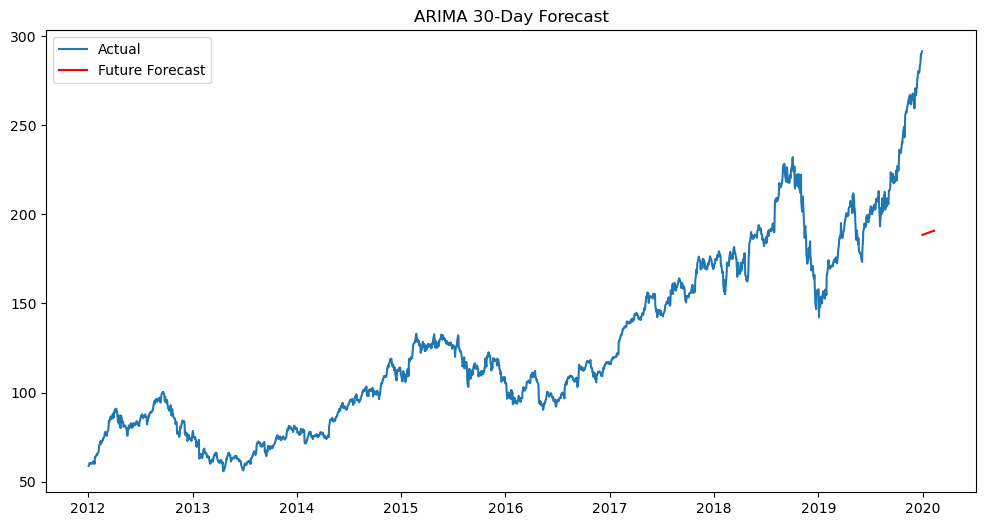

In [41]:
## plot actual and future forecast
plt.figure(figsize=(12,6))
plt.plot(ts, label='Actual')
plt.plot(future_forecast, label='Future Forecast', color='red')
plt.title("ARIMA 30-Day Forecast")
plt.legend()
plt.show()

### SARIMA

In [42]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [43]:
## fit sarima model
model = SARIMAX(train,order=(1,1,1),seasonal_order=(1,1,1,5),enforce_stationarity=False,enforce_invertibility=False)
sarima_model = model.fit()

In [44]:
# Forecast
start = len(train)
end = len(train) + len(test) - 1
sarima_pred = sarima_model.predict(start=start, end=end)
sarima_pred.index = test.index

In [45]:
# Evaluation
sarima_mae = mean_absolute_error(test, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred))
print("SARIMA MAE:", sarima_mae)
print("SARIMA RMSE:", sarima_rmse)

SARIMA MAE: 20.76532047665834
SARIMA RMSE: 26.370468083459315


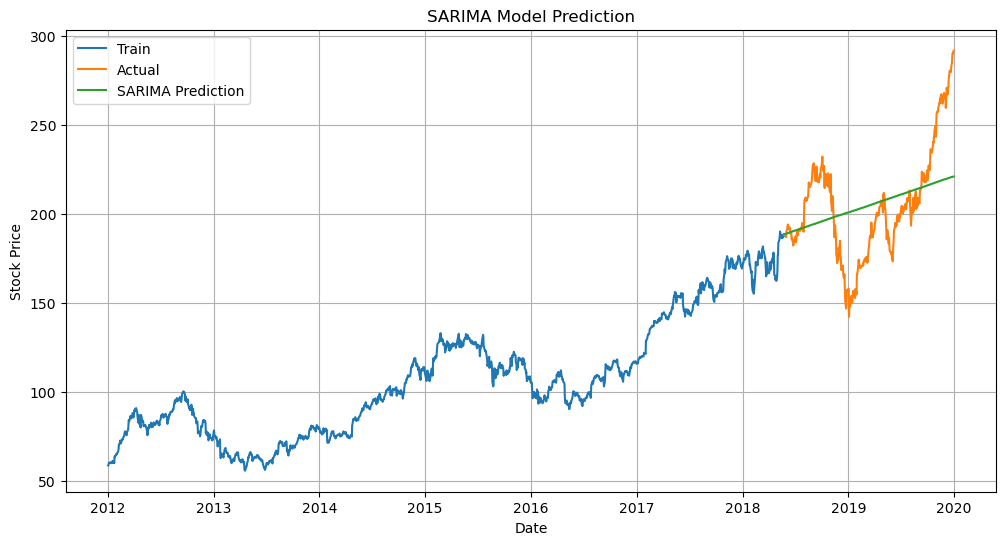

In [46]:
# Plot train,actual and predicted
plt.figure(figsize=(12,6))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(sarima_pred, label='SARIMA Prediction')
plt.title("SARIMA Model Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
## future forecast
future_steps = 30
future_forecast = sarima_model.forecast(steps=future_steps)
future_dates = pd.date_range(start=ts.index[-1], periods=future_steps+1, freq='B')[1:]
future_forecast = pd.Series(future_forecast.values, index=future_dates)
future_forecast

2019-12-31    188.560138
2020-01-01    188.585826
2020-01-02    188.654337
2020-01-03    188.758853
2020-01-06    188.813984
2020-01-07    188.948070
2020-01-08    188.993605
2020-01-09    189.056196
2020-01-10    189.162485
2020-01-13    189.217143
2020-01-14    189.351397
2020-01-15    189.396881
2020-01-16    189.459488
2020-01-17    189.565772
2020-01-20    189.620431
2020-01-21    189.754685
2020-01-22    189.800169
2020-01-23    189.862776
2020-01-24    189.969060
2020-01-27    190.023719
2020-01-28    190.157973
2020-01-29    190.203457
2020-01-30    190.266064
2020-01-31    190.372348
2020-02-03    190.427007
2020-02-04    190.561261
2020-02-05    190.606746
2020-02-06    190.669352
2020-02-07    190.775636
2020-02-10    190.830295
Freq: B, dtype: float64

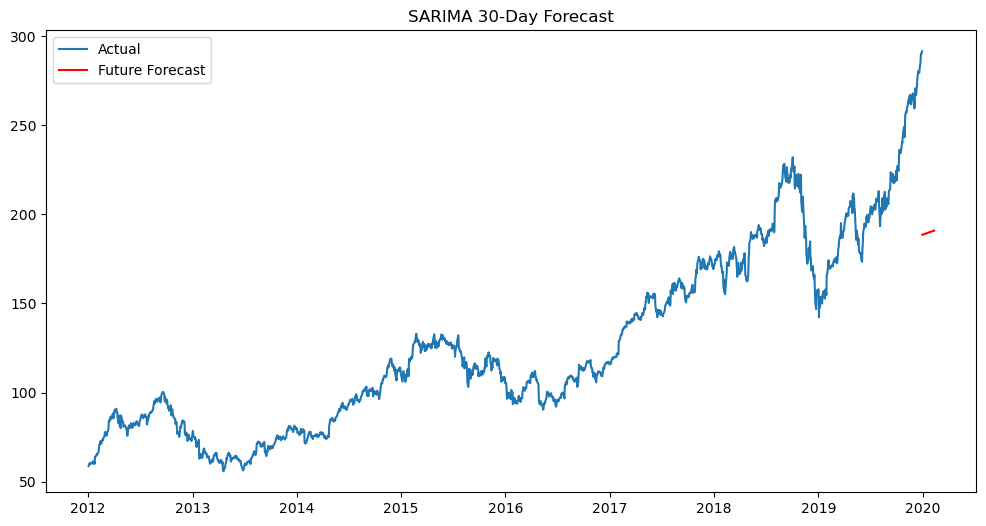

In [48]:
## plot actual and foture forecastt
plt.figure(figsize=(12,6))
plt.plot(ts, label='Actual')
plt.plot(future_forecast, label='Future Forecast', color='red')
plt.title("SARIMA 30-Day Forecast")
plt.legend()
plt.show()

### LSTM

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [50]:
data = df[['Close']].values

In [51]:
# Scale the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [52]:
# Create sequences
def create_sequences(data, window=60):
    x, y = [], []
    for i in range(window, len(data)):
        x.append(data[i-window:i])
        y.append(data[i])
    return np.array(x), np.array(y)

In [53]:
window_size = 60
x, y = create_sequences(scaled_data, window_size)

In [54]:
# Train-test split
split = int(len(x) * 0.8)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]

In [55]:
def build_lstm_model(units, input_shape):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(units))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

In [56]:
units_list = [32, 50]
batch_sizes = [16, 32]
epochs_list = [20, 30]

In [57]:
best_rmse = float('inf')
best_params = {}
for units in units_list:
    for batch in batch_sizes:
        for epochs in epochs_list:
            model = build_lstm_model(units, (x_train.shape[1], 1))
            history = model.fit(
                x_train, y_train,
                epochs=epochs,
                batch_size=batch,
                verbose=0)
            preds = model.predict(x_test)
            preds = scaler.inverse_transform(preds)
            y_true = scaler.inverse_transform(y_test)

            rmse = np.sqrt(mean_squared_error(y_true, preds))

            print(f"Units={units}, Batch={batch}, Epochs={epochs} → RMSE={rmse:.4f}")

            if rmse < best_rmse:
                best_rmse = rmse
                best_params = {
                    'units': units,
                    'batch_size': batch,
                    'epochs': epochs}
print("Best Parameters:", best_params)
print("Best RMSE:", best_rmse)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step 
Units=32, Batch=16, Epochs=20 → RMSE=5.0534
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step 
Units=32, Batch=16, Epochs=30 → RMSE=4.5370
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step 
Units=32, Batch=32, Epochs=20 → RMSE=5.5562
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step 
Units=32, Batch=32, Epochs=30 → RMSE=6.0393
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step 
Units=50, Batch=16, Epochs=20 → RMSE=4.6146
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step 
Units=50, Batch=16, Epochs=30 → RMSE=5.1223
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step 
Units=50, Batch=32, Epochs=20 → RMSE=5.2100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step 
Units=50, Batch=32, Epochs=30 → RMSE=4.4722
Best Parameters: {'units': 50, 'batch_size': 32, 'epochs': 30}
Best RMSE: 4.47222270621671


In [58]:
## build model
model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    LSTM(32),Dense(1)])
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                       │ (None, 60, 32)              │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_17 (LSTM)                       │ (None, 32)                  │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,705 (49.63 KB)

 Trainable params: 12,705 (49.63 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
## train the model
history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(x_test, y_test),
    verbose=1)

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - loss: 0.0051 - val_loss: 0.0022
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 4.0015e-04 - val_loss: 0.0022
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 3.6870e-04 - val_loss: 0.0019
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 3.3958e-04 - val_loss: 0.0015
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 3.5173e-04 - val_loss: 0.0013
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 2.9302e-04 - val_loss: 0.0029
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 2.7202e-04 - val_loss: 9.2794e-04
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 2.3962e-04 - val_loss: 0.0011
Epoch 9/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 2.2520e-04 - val_loss: 7.2565e-04
Epoch 10/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 2.3559e-04 - val_loss: 7.0650e-04
Epoch 11/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 2.1213e-04 - val_loss: 9.1519e-04
E

In [60]:
## prediction
predicted = model.predict(x_test)
# Inverse scaling
predicted = scaler.inverse_transform(predicted)
y_test_inv = scaler.inverse_transform(y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step 


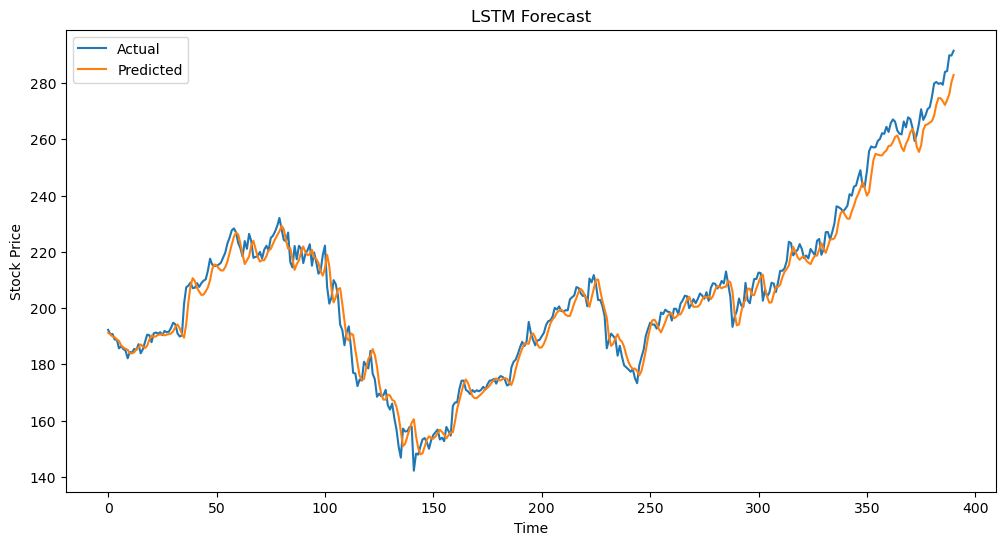

In [61]:
## plot prediction
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Actual")
plt.plot(predicted, label="Predicted")
plt.title("LSTM Forecast")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [63]:
## evaluation
lstm_mae = mean_absolute_error(y_test_inv, predicted)
lstm_rmse = np.sqrt(mean_squared_error(y_test_inv, predicted))
print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)

LSTM MAE: 3.7634180790516063
LSTM RMSE: 4.877299002161238


In [64]:
# Number of days to forecast
n_future = 30
# Last window from scaled data (same window size used in training)
last_window = scaled_data[-60:]  # shape (60, 1)
# Reshape to LSTM input format
current_input = last_window.reshape(1, 60, 1)

In [65]:
future_predictions = []
for _ in range(n_future):
    # Predict next value
    next_pred = model.predict(current_input, verbose=0)[0][0]
    # Store prediction
    future_predictions.append(next_pred)
    # Update input window
    current_input = np.append(
        current_input[:, 1:, :],
        [[[next_pred]]],
        axis=1)

In [66]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1))

In [67]:
future_dates = pd.date_range(
    start=df.index[-1],
    periods=n_future + 1,
    freq='B')[1:]

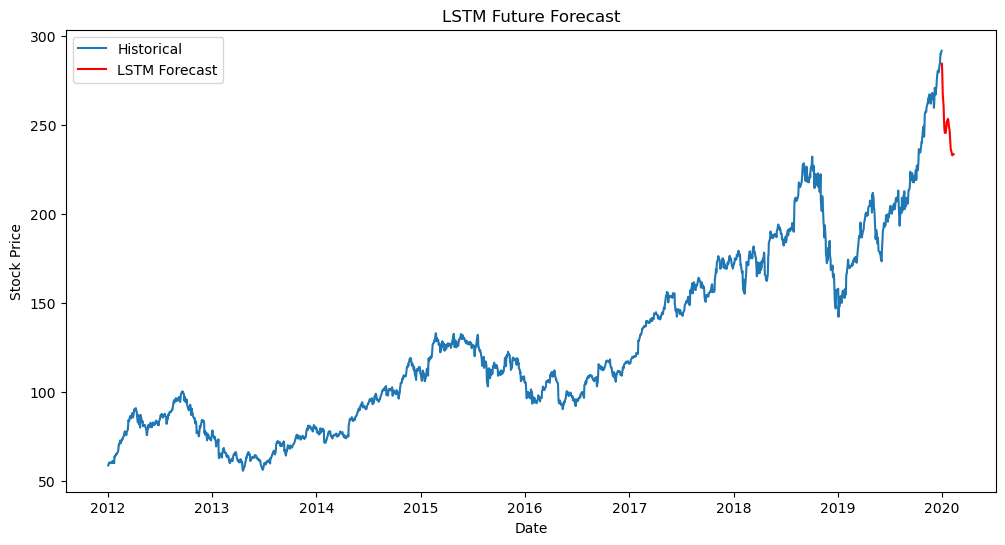

In [68]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Historical')
plt.plot(future_dates, future_predictions, label='LSTM Forecast', color='red')
plt.title("LSTM Future Forecast")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

### XGBOOST

In [69]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

In [70]:
# Select features and target
x = df.drop('Close', axis=1)
y = df['Close']

In [71]:
# Train-test split (time series split)
split = int(len(df) * 0.8)
x_train, x_test = x.iloc[:split], x.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [72]:
## parameters for grid search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [73]:
## grid Search
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42)
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1)
grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='neg_mean_squared_error', verbose=1)

In [74]:
## best model 
best_xgb = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}


In [75]:
## model evaluation
y_pred = best_xgb.predict(x_test)
xgb_mae = mean_absolute_error(y_test, y_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)

XGBoost MAE: 20.777744607070506
XGBoost RMSE: 32.03179762157186


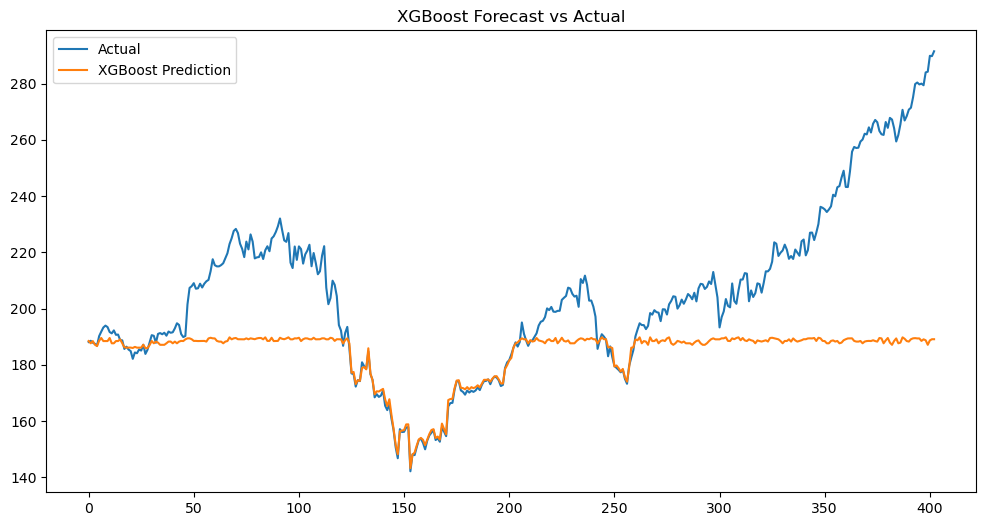

In [76]:
##  plot actual and predicted
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='XGBoost Prediction')
plt.legend()
plt.title("XGBoost Forecast vs Actual")
plt.show()

In [77]:
## future forecast
# Number of future days
n_future = 30

# Copy last row of lag features
last_input = x.iloc[-1].values.reshape(1, -1)

future_preds = []

for _ in range(n_future):
    # Predict next value
    next_pred = best_xgb.predict(last_input)[0]
    future_preds.append(next_pred)

    # Shift values and append new prediction
    last_input = np.roll(last_input, -1)
    last_input[0, -1] = next_pred


In [78]:
## convert to dataframe
future_dates = pd.date_range(
    start=df.index[-1],
    periods=n_future + 1,
    freq='B'
)[1:]

future_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast': future_preds
})


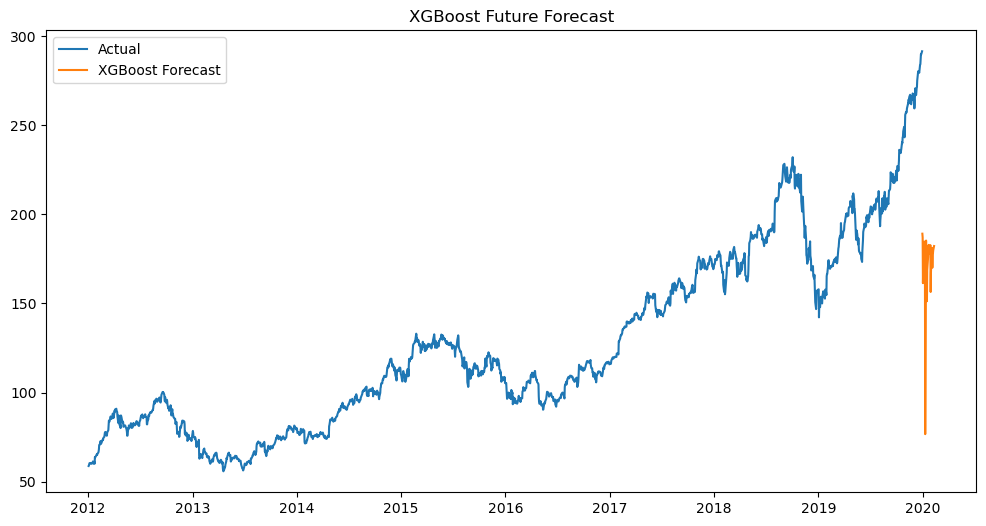

In [79]:
##plot future forecast
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Actual')
plt.plot(future_df['Date'], future_df['Forecast'], label='XGBoost Forecast')
plt.legend()
plt.title("XGBoost Future Forecast")
plt.show()

### Comparison

In [84]:
comparison_data =pd.DataFrame( {"Model": ["ARIMA", "SARIMA", "LSTM", "XGBoost"],
    "MAE": [arima_mae,sarima_mae,lstm_mae,xgb_mae],
    "RMSE": [arima_rmse,sarima_rmse,lstm_rmse,xgb_rmse]})
comparison_data

,Model,MAE,RMSE
0,ARIMA,20.755123,26.370173
1,SARIMA,20.765320,26.370468
2,LSTM,3.763418,4.877299
3,XGBoost,20.777745,32.031798


### Deployment of LSTM

In [87]:
model.save("lstm_stock_model.keras")